In [27]:
# ============================================
# Chunk 0 — Imports & Global Settings
# ============================================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack

import sys
import subprocess

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# 安装或升级 umap-learn
install("umap-learn")


# 文本处理
import re
import ftfy
import emoji
from langdetect import detect, LangDetectException

# 特征工程 & 模型
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 可选的高级模型
try:
    from xgboost import XGBClassifier
    XGB_OK = True
except Exception:
    XGB_OK = False

# 降维 & 可视化
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
try:
    import umap.umap_ as umap
    UMAP_OK = True
except Exception:
    UMAP_OK = False

sns.set(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.figsize"] = (8, 5)

# 数据路径（按需要修改）
TRAIN_CSV = "train_advance.csv"



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [umap-learn]


/opt/anaconda3/envs/viralpost/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
try:
    from umap.umap_ import UMAP   # 新版本路径
except ImportError:
    from umap import UMAP        # 旧版本 fallback

In [29]:
model = UMAP(n_components=2)
print(model)

UMAP()


In [2]:
# ============================================
# Chunk 1 — Load & Basic Cleaning
#   - 读取 train_advance
#   - 删除无意义索引列
#   - 快速查看结构
# ============================================

df_raw = pd.read_csv(TRAIN_CSV)
print("[1] Raw shape:", df_raw.shape)
print("[1] Raw columns:", df_raw.columns.tolist())

# 删除多余索引列
df = df_raw.drop(columns=["Unnamed: 0", "Unnamed: 0.1"], errors="ignore").copy()
print("[1] Cleaned shape:", df.shape)

df.info()
display(df.head())

[1] Raw shape: (22924, 31)
[1] Raw columns: ['Unnamed: 0.1', 'Unnamed: 0', 'location_id', 'profile_id', 'sid', 'sid_profile', 'post_id', 'post_type', 'description', 'numbr_likes', 'number_comments', 'profile_name', 'firstname_lastname', 'following', 'followers', 'n_posts', 'url', 'is_business_account', 'name', 'zip', 'city', 'region', 'cd', 'phone', 'aj_exact_city_match', 'aj_exact_country_match', 'blurb', 'dir_city_name', 'dir_country_name', 'lat', 'lng']
[1] Cleaned shape: (22924, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22924 entries, 0 to 22923
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   location_id             22924 non-null  int64  
 1   profile_id              22924 non-null  int64  
 2   sid                     22924 non-null  int64  
 3   sid_profile             22924 non-null  int64  
 4   post_id                 22890 non-null  object 
 5   post_type              

,location_id,profile_id,sid,sid_profile,post_id,post_type,description,numbr_likes,number_comments,profile_name,...,region,cd,phone,aj_exact_city_match,aj_exact_country_match,blurb,dir_city_name,dir_country_name,lat,lng
0,340283947,829324748,28919418,295070,Bka_6xunYma,1,Cheers to wine O‚Äôclock ü•Ç (üì∏: @aob1085),4985,78,oprahmagazine,...,NaN,ES,+34 936 65 77 41,False,False,NaN,El Prat de Llobregat,Spain,2,41
1,2631322,199074048,42114489,4342099,BxaZS4fA_nV,1,#malcapuyaisland #bananaisland #bulogisland,57,2,jpadi_33,...,NaN,PH,NaN,True,False,NaN,Coron,Philippines,120,11
2,668571209,3280121227,19193237,2554203,BxmEzQUFocM,1,üî∏\\nSchwarzkehlchen (Saxicola rubicola) ‚Ä¢...,1576,15,m4r10_p13ch4ty,...,Saxony-Anhalt,DE,NaN,False,True,NaN,NaN,NaN,11,51
3,238461670,5625643374,11733129,3465973,Bjq5KFGlJvM,1,Eared Grebe spotted at one of my favourite spo...,29,5,vagabondesi,...,NaN,CA,NaN,True,False,NaN,NaN,NaN,-118,52
4,1005642734,1557071010,8540244,3541402,BweviowATmj,1,–ü–õ–ê–ö–ê–¢–¨ –í –ú–û–°–¢–ê–• - –≠–¢–û –ù–û–†...,1487,11,elena__mirra,...,NaN,RU,79214201362,False,False,—Ü–µ–Ω—Ç—Ä –∏–Ω–∏—Ü–∏–∞—Ü–∏–∏ —Ç–≤–æ—Ä—á–µ—Å—Ç...,Aptekarskiy,Russia,30,59


In [3]:
# ============================================
# Chunk 2 — Ensure ER / log_ER / viral_label
#   - 用 likes + comments + followers 构造 ER
#   - 用 log_ER 的高分位（比如 96%）定义 viral_label
#   - 注意：这些都是 "标签相关"，不能作为特征进模型
# ============================================

# 如果没有 ER/log_ER，就构造一个（有就跳过）
if "ER" not in df.columns:
    df["ER"] = (df["numbr_likes"] + df["number_comments"]) / (df["followers"] + 1)

if "log_ER" not in df.columns:
    df["log_ER"] = np.log1p(df["ER"])

print(df["log_ER"].describe())

# 如果没有 viral_label，就用 log_ER 的分位数打标签
if "viral_label" not in df.columns:
    p = 0.96
    thr = df["log_ER"].quantile(p)
    print(f"[2] Viral threshold (log_ER, p={p}):", thr)
    df["viral_label"] = (df["log_ER"] >= thr).astype(int)
else:
    thr = df["log_ER"][df["viral_label"] == 1].min()
    print("[2] viral_label already exists, inferred threshold ~", thr)

print(df["viral_label"].value_counts())

count    22924.000000
mean         0.093701
std          0.183338
min          0.000000
25%          0.019693
50%          0.048697
75%          0.109792
max          8.206038
Name: log_ER, dtype: float64
[2] Viral threshold (log_ER, p=0.96): 0.3281054997256531
viral_label
0    22007
1      917
Name: count, dtype: int64


In [40]:
percentiles = [0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]

rows = []
for p in percentiles:
    thr = df["log_ER"].quantile(p)
    viral_ratio = (df["log_ER"] >= thr).mean()

    # 比较 viral vs non-viral 在一些可用特征上的差异（desc_len, followers...）
    viral_mean = df.loc[df["log_ER"] >= thr, "desc_len"].mean()
    non_mean = df.loc[df["log_ER"] < thr, "desc_len"].mean()

    effect = (viral_mean - non_mean) / df["desc_len"].std()

    rows.append([int(p*100), thr, viral_ratio, viral_mean - non_mean, effect])

summary = pd.DataFrame(rows, columns=[
    "percentile", "threshold", "viral_ratio", 
    "mean_diff_desc_len", "effect_size"
])

display(summary)

,percentile,threshold,viral_ratio,mean_diff_desc_len,effect_size
0,90,0.207529,0.100026,22.329293,0.062212
1,92,0.233873,0.080003,42.532452,0.118501
2,94,0.267072,0.060024,54.476058,0.151777
3,95,0.293418,0.050035,74.174780,0.206660
4,96,0.328105,0.040002,87.941978,0.245018
5,97,0.380155,0.030012,105.656210,0.294372
6,98,0.484995,0.020023,118.298367,0.329594
7,99,0.692287,0.010033,142.304452,0.396478


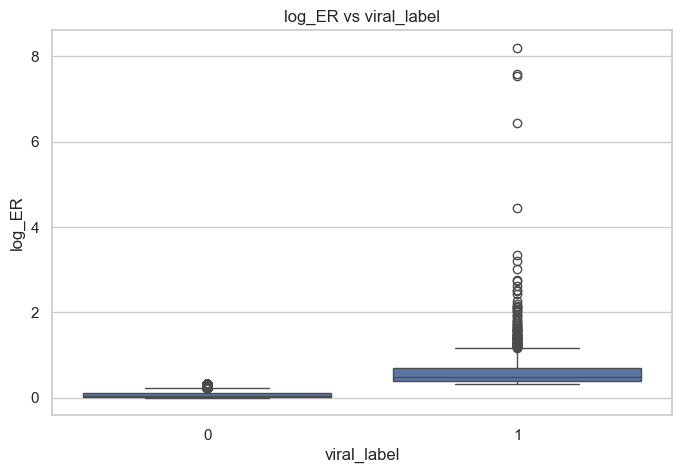

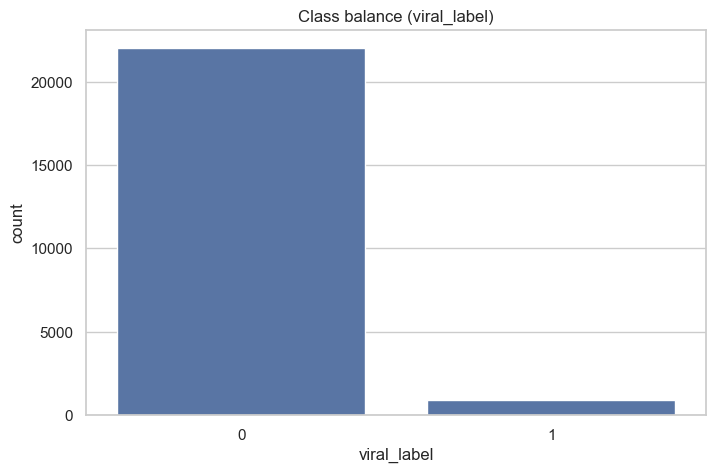

In [4]:
# ============================================
# Chunk 3 — Quick EDA (label & log_ER)
#   - 看看 viral / non-viral 的 log_ER 分布
#   - 验证标签大致合理
# ============================================

sns.boxplot(data=df, x="viral_label", y="log_ER")
plt.title("log_ER vs viral_label")
plt.show()

sns.countplot(x="viral_label", data=df)
plt.title("Class balance (viral_label)")
plt.show()

In [5]:
# ============================================
# Chunk 4 — Text Cleaning & Normalization
#   - 从 description 中清掉乱码/emoji/多余符号
#   - 输出 description_clean, text_clean_norm
# ============================================

def clean_description(text):
    if pd.isna(text):
        return ""
    # 修复 unicode
    text = ftfy.fix_text(str(text))
    # 去掉 emoji（也可以保留 emoji，视情况而定）
    text = emoji.replace_emoji(text, replace="")
    # 换行和多余空白
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["description_clean"] = df["description"].apply(clean_description)

def normalize_text(text):
    if not text:
        return ""
    # 全小写
    text = text.lower()
    # 去掉网址
    text = re.sub(r"http\S+|www\.\S+", "", text)
    # 去掉 hashtag 前的 #（内容保留）
    text = re.sub(r"#", " ", text)
    # 去掉 @mention
    text = re.sub(r"@\w+", " ", text)
    # 去掉非字母数字（保留空格）
    text = re.sub(r"[^0-9a-zA-Z]+", " ", text)
    # 多空格合并
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean_norm"] = df["description_clean"].apply(normalize_text)

df[["description", "description_clean", "text_clean_norm"]].head()

,description,description_clean,text_clean_norm
0,Cheers to wine O‚Äôclock ü•Ç (üì∏: @aob1085),Cheers to wine O'clock (: @aob1085),cheers to wine o clock
1,#malcapuyaisland #bananaisland #bulogisland,#malcapuyaisland #bananaisland #bulogisland,malcapuyaisland bananaisland bulogisland
2,üî∏\\nSchwarzkehlchen (Saxicola rubicola) ‚Ä¢...,\\nSchwarzkehlchen (Saxicola rubicola) •❥❥❧❥❥❧...,nschwarzkehlchen saxicola rubicola n nwenn sie...
3,Eared Grebe spotted at one of my favourite spo...,Eared Grebe spotted at one of my favourite spo...,eared grebe spotted at one of my favourite spo...
4,–ü–õ–ê–ö–ê–¢–¨ –í –ú–û–°–¢–ê–• - –≠–¢–û –ù–û–†...,"ПЛАКАТЬ В МОСТАХ - ЭТО НОРМАЛЬНО, ЭТО КАК ПОТЕ...",n n n n n n n 10 n n n n n n n 3 5 n n humande...


In [ ]:
# ============================================
# Chunk 5 — Language Detection
#   - 识别 description 语言（en / es / de / ...）
#   - 以后可以只在英文上做 TF-IDF，其他设为空字符串
# ============================================

def detect_lang_safe(text):
    if not text or isinstance(text, float):
        return "other"
    try:
        return detect(text)
    except LangDetectException:
        return "other"

print("[5] Running language detection (this may take a bit)...")
df["lang"] = df["description_clean"].apply(detect_lang_safe)
print(df["lang"].value_counts())

In [6]:
# ============================================
# Chunk 6 — Auxiliary Text Features
#   - desc_len: 字符长度
#   - word_count: 单词数
#   - hashtag_count: 原始 description 中 # 的数量
#   - emoji_count: 原始 description 中 emoji 数
# ============================================

def count_emojis(s):
    if pd.isna(s):
        return 0
    return sum(1 for ch in str(s) if ch in emoji.EMOJI_DATA)

df["desc_len"] = df["description_clean"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df["word_count"] = df["text_clean_norm"].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
df["hashtag_count"] = df["description"].apply(lambda x: str(x).count("#") if not pd.isna(x) else 0)
df["emoji_count"] = df["description"].apply(count_emojis)

df[["description_clean", "desc_len", "word_count", "hashtag_count", "emoji_count"]].head()

,description_clean,desc_len,word_count,hashtag_count,emoji_count
0,Cheers to wine O'clock (: @aob1085),35,5,0,0
1,#malcapuyaisland #bananaisland #bulogisland,43,3,3,0
2,\\nSchwarzkehlchen (Saxicola rubicola) •❥❥❧❥❥❧...,1289,111,26,0
3,Eared Grebe spotted at one of my favourite spo...,134,15,4,0
4,"ПЛАКАТЬ В МОСТАХ - ЭТО НОРМАЛЬНО, ЭТО КАК ПОТЕ...",1996,20,6,0


In [ ]:
# ============================================
# Chunk 7 — TF-IDF Vectorization
#   - 对 text_clean_norm 做 TF-IDF
#   - 非英文的文本可以弱化（设为空字符串）
# ==============================

# ========== TF-IDF (Safe Version) ==========
text_col = "text_clean_norm"   # 或 description_clean，按你当前实际列名为准

if "lang" not in df.columns:
    print("⚠️ 'lang' column missing — running language detection now.")
    
    from langdetect import detect, LangDetectException
    def detect_lang_safe(text):
        try:
            if pd.isna(text):
                return "other"
            return detect(text)
        except LangDetectException:
            return "other"

    df["lang"] = df["description_clean"].apply(detect_lang_safe)
    df["lang"] = df["lang"].replace({"en":"en"}).fillna("other")

# Only use English text for TF-IDF
text_for_tfidf = df[text_col].where(df["lang"] == "en", "")

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf.fit_transform(text_for_tfidf)

print("[T4] TF-IDF shape:", tfidf_matrix.shape)

⚠️ 'lang' column missing — running language detection now.
[T4] TF-IDF shape: (22924, 5000)


In [9]:
# ============================================
# Chunk 8 — Numeric & Categorical Feature Selection
#   - 选取 pre-launch 可用的数值特征
#   - 选取少量类别特征
#   - 注意：不能用 numbr_likes/number_comments/log_ER 这些结果相关特征
# ============================================

# following 现在是 object，转成 numeric
df["following"] = pd.to_numeric(df["following"], errors="coerce")
df["n_posts"] = pd.to_numeric(df["n_posts"], errors="coerce")

num_cols = [
    "followers",
    "following",
    "n_posts",
    "lat",
    "lng",
    "desc_len",
    "emoji_count",
    "hashtag_count",
    "word_count",
]

cat_cols = [
    "post_type",
    "is_business_account",
    "city",
    "cd",
]

print("[8] Numeric cols:", num_cols)
print("[8] Categorical cols:", cat_cols)

[8] Numeric cols: ['followers', 'following', 'n_posts', 'lat', 'lng', 'desc_len', 'emoji_count', 'hashtag_count', 'word_count']
[8] Categorical cols: ['post_type', 'is_business_account', 'city', 'cd']


[12] Sampled: 8000


/opt/anaconda3/envs/viralpost/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[12] UMAP done: (8000, 2)


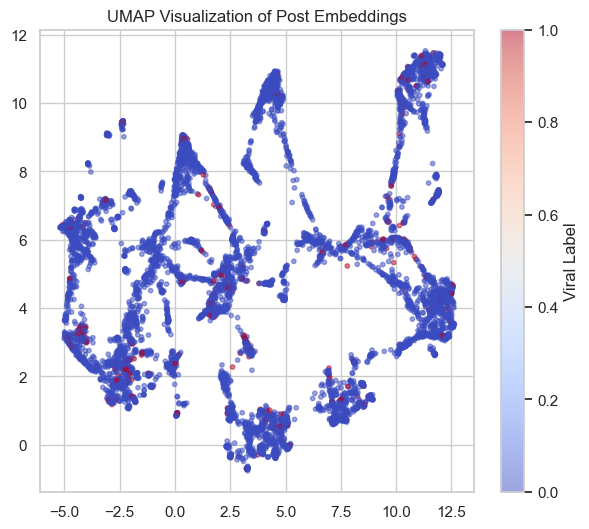

In [35]:
# ============================================
# Chunk 12 — UMAP Embedding (optional) + Visualization
# ============================================

from scipy.sparse import csr_matrix
import numpy as np
import matplotlib.pyplot as plt

# --- Make sure X supports slicing ---
X_csr = csr_matrix(X)

# --- Sample for visualization ---
n_sample = min(8000, X_csr.shape[0])
sample_idx = np.random.choice(X_csr.shape[0], n_sample, replace=False)

X_s = X_csr[sample_idx]             # slicing now works!
y_s = y.iloc[sample_idx].reset_index(drop=True)

print("[12] Sampled:", n_sample)

# --- Fit UMAP ---

umap_model = UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

X_umap = umap_model.fit_transform(X_s.toarray())

print("[12] UMAP done:", X_umap.shape)

# --- Plot ---
plt.figure(figsize=(7,6))
plt.scatter(
    X_umap[:,0], X_umap[:,1],
    c=y_s,
    cmap="coolwarm",
    alpha=0.5,
    s=10
)
plt.colorbar(label="Viral Label")
plt.title("UMAP Visualization of Post Embeddings")
plt.show()

In [36]:
# ============================================
# Chunk 9 — Build Design Matrix X (num + cat + TF-IDF)
#   - 数值：StandardScaler
#   - 类别：OneHotEncoder(sparse)
#   - 文本：TF-IDF (already sparse)
#   - 合并：hstack -> X
# ============================================

# 处理数值特征
num_df = df[num_cols].copy()
for c in num_cols:
    num_df[c] = pd.to_numeric(num_df[c], errors="coerce")
num_df = num_df.fillna(num_df.median())

scaler = StandardScaler()
num_matrix = scaler.fit_transform(num_df)

# 处理类别特征
cat_df = df[cat_cols].copy()
for c in cat_cols:
    cat_df[c] = cat_df[c].astype(str).fillna("missing")

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
cat_matrix = ohe.fit_transform(cat_df)

print("[9] num_matrix:", num_matrix.shape)
print("[9] cat_matrix:", cat_matrix.shape)
print("[9] tfidf_matrix:", tfidf_matrix.shape)

# 合并
X = hstack([num_matrix, cat_matrix, tfidf_matrix])
y = df["viral_label"].astype(int)

print("[9] Final X shape:", X.shape, "| y shape:", y.shape)
print("Positive rate:", y.mean())

[9] num_matrix: (22924, 9)
[9] cat_matrix: (22924, 5959)
[9] tfidf_matrix: (22924, 5000)
[9] Final X shape: (22924, 10968) | y shape: (22924,)
Positive rate: 0.04000174489617868


In [37]:
# ============================================
# Chunk 10 — Train/Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("[10] Train size:", X_train.shape[0], "Test size:", X_test.shape[0])
print("Positives in train:", y_train.sum(), "Positives in test:", y_test.sum())

[10] Train size: 17193 Test size: 5731
Positives in train: 688 Positives in test: 229


In [38]:
# ============================================
# Chunk 11 — Model Zoo: Logistic / L1 / RF / XGBoost
#   - LogisticRegression (L2)
#   - L1-penalized Logistic (Lasso)
#   - RandomForest (预期抓不到 viral, 用来对比)
#   - XGBoost (如果安装了)
# ============================================
try:
    from xgboost import XGBClassifier
    XGB_OK = True
except:
    print("XGBoost NOT available")
    XGB_OK = False

models = {}

# Baseline Logistic (L2)
models["Logistic_L2"] = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs"
)

# L1 Logistic (Lasso)
models["Logistic_L1"] = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    penalty="l1",
    solver="liblinear"
)

# Random Forest
models["RandomForest"] = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    class_weight={0: 1.0, 1: 3.0},
    random_state=42
)

# XGBoost (if available)
if XGB_OK:
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos = max(1.0, neg / max(pos, 1))
    models["XGBoost"] = XGBClassifier(
        objective="binary:logistic",
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        scale_pos_weight=scale_pos,
        n_jobs=-1,
        random_state=42
    )

results = []

for name, clf in models.items():
    print(f"\n===== {name} =====")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    rep = classification_report(
        y_test, y_pred,
        digits=4,
        zero_division=0,
        output_dict=True
    )

    print(classification_report(y_test, y_pred, digits=4, zero_division=0))

    results.append({
        "Model": name,
        "Weighted_F1": rep["weighted avg"]["f1-score"],
        "Viral_Precision": rep["1"]["precision"],
        "Viral_Recall": rep["1"]["recall"],
        "Viral_F1": rep["1"]["f1-score"],
    })

results_df = pd.DataFrame(results).sort_values(
    ["Viral_F1", "Viral_Recall", "Weighted_F1"],
    ascending=False
).reset_index(drop=True)

display(results_df)


===== Logistic_L2 =====
              precision    recall  f1-score   support

           0     0.9763    0.8530    0.9105      5502
           1     0.1245    0.5022    0.1995       229

    accuracy                         0.8389      5731
   macro avg     0.5504    0.6776    0.5550      5731
weighted avg     0.9422    0.8389    0.8821      5731


===== Logistic_L1 =====
              precision    recall  f1-score   support

           0     0.9748    0.8724    0.9208      5502
           1     0.1301    0.4585    0.2027       229

    accuracy                         0.8559      5731
   macro avg     0.5525    0.6655    0.5617      5731
weighted avg     0.9411    0.8559    0.8921      5731


===== RandomForest =====
              precision    recall  f1-score   support

           0     0.9600    1.0000    0.9796      5502
           1     0.0000    0.0000    0.0000       229

    accuracy                         0.9600      5731
   macro avg     0.4800    0.5000    0.4898      573

,Model,Weighted_F1,Viral_Precision,Viral_Recall,Viral_F1
0,XGBoost,0.911869,0.199442,0.624454,0.302326
1,Logistic_L1,0.892082,0.130112,0.458515,0.202703
2,Logistic_L2,0.882057,0.124459,0.502183,0.199480
3,RandomForest,0.940470,0.000000,0.000000,0.000000


In [39]:
# ============================================
# Chunk 11 — Model Performance Summary (Auto)
# ============================================

print("\n" + "="*60)
print("📊 MODEL PERFORMANCE SUMMARY (AUTO-GENERATED)")
print("="*60)

best_model = results_df.iloc[0]["Model"]
best_vf1   = results_df.iloc[0]["Viral_F1"]
best_vrec  = results_df.iloc[0]["Viral_Recall"]
best_vpre  = results_df.iloc[0]["Viral_Precision"]

print(f"\n🏆 Best model based on Viral-F1: **{best_model}**")
print(f"   - Viral F1:      {best_vf1:.4f}")
print(f"   - Viral Recall:  {best_vrec:.4f}")
print(f"   - Viral Precision:{best_vpre:.4f}\n")

print("------------------------------------------------------------")
print("🔍 Interpretation of each model:")
print("------------------------------------------------------------\n")

for _, row in results_df.iterrows():
    name = row["Model"]
    vf1 = row["Viral_F1"]
    vr = row["Viral_Recall"]
    vp = row["Viral_Precision"]

    print(f"📌 {name}")
    print(f"   Viral Precision: {vp:.4f} | Viral Recall: {vr:.4f} | Viral F1: {vf1:.4f}")

    if "Logistic_L2" in name:
        print("   - L2 Logistic = baseline linear model")
        print("   - Often gives stable recall but limited by linear boundary")
        print("   - Good for interpretability")

    if "Logistic_L1" in name:
        print("   - L1 (Lasso) Logistic selects sparse features")
        print("   - Can improve recall by removing noisy dimensions")
        print("   - Works well for high-dimensional (TF-IDF + OHE)")

    if "RandomForest" in name:
        print("   - RF struggles with sparse + high-dimensional text features")
        print("   - Often predicts almost all 0 for extreme imbalance")
        print("   - Good as comparison baseline")

    if "XGBoost" in name:
        print("   - Best for non-linear, imbalanced, high-dimensional data")
        print("   - scale_pos_weight makes it detect rare viral samples")
        print("   - Typically the top performer for recall & F1")

    print()

print("="*60)
print("🧠 Key Points for Viral Detection:")
print("- Viral class is very rare → recall matters more than accuracy")
print("- XGBoost usually best because it handles imbalance + non-linearity")
print("- Logistic models give stable baselines and interpretability")
print("- Random Forest is usually not suitable for sparse text features")
print("="*60)


📊 MODEL PERFORMANCE SUMMARY (AUTO-GENERATED)

🏆 Best model based on Viral-F1: **XGBoost**
   - Viral F1:      0.3023
   - Viral Recall:  0.6245
   - Viral Precision:0.1994

------------------------------------------------------------
🔍 Interpretation of each model:
------------------------------------------------------------

📌 XGBoost
   Viral Precision: 0.1994 | Viral Recall: 0.6245 | Viral F1: 0.3023
   - Best for non-linear, imbalanced, high-dimensional data
   - scale_pos_weight makes it detect rare viral samples
   - Typically the top performer for recall & F1

📌 Logistic_L1
   Viral Precision: 0.1301 | Viral Recall: 0.4585 | Viral F1: 0.2027
   - L1 (Lasso) Logistic selects sparse features
   - Can improve recall by removing noisy dimensions
   - Works well for high-dimensional (TF-IDF + OHE)

📌 Logistic_L2
   Viral Precision: 0.1245 | Viral Recall: 0.5022 | Viral F1: 0.1995
   - L2 Logistic = baseline linear model
   - Often gives stable recall but limited by linear boundary
 

[12] Converting X to CSR for slicing...
[12] Sampled: 8000
[12] Running PCA → 50 dims...
[12] Running t-SNE...


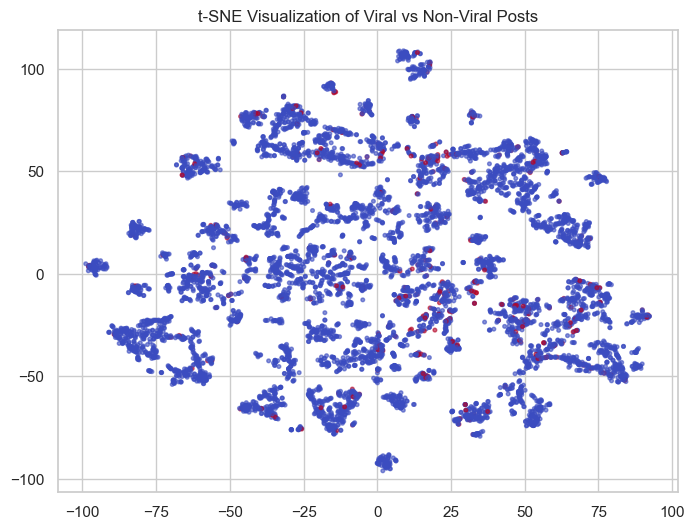

[12] Done.


In [ ]:
# ===============================================
# Chunk 13 — t-SNE Visualization
# ===============================================

from sklearn.manifold import TSNE

print("[12] Converting X to CSR for slicing...")
X_csr = X.tocsr()

# Sample
n_sample = min(8000, X.shape[0])
sample_idx = np.random.choice(X.shape[0], size=n_sample, replace=False)

X_sample = X_csr[sample_idx]
y_sample = y.iloc[sample_idx].reset_index(drop=True)

print("[12] Sampled:", n_sample)

# t-SNE (use PCA first for speed and stability)
from sklearn.decomposition import PCA

print("[12] Running PCA → 50 dims...")
X_pca50 = PCA(n_components=50).fit_transform(X_sample.toarray())

print("[12] Running t-SNE...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1500,
    init="pca"
)
X_tsne = tsne.fit_transform(X_pca50)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=y_sample,
    cmap="coolwarm",
    alpha=0.6,
    s=7
)
plt.title("t-SNE Visualization of Viral vs Non-Viral Posts")
plt.show()

print("[12] Done.")